# L=32 XY — direct raw-PCA versus frozen-ResNet comparison

Both representations use the same 4.1 million seed–temperature–bin observations, the same balanced PCA-fit indices, the same spectral landmark indices, and the same diagnostic indices.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_mutual_info_score

OUT=Path('/home/lledson/senior-thesis/data/processed/xy32_broad/matched_all_bins')
raw=json.loads((OUT/'raw_spin_summary.json').read_text())
res=json.loads((OUT/'resnet18_summary.json').read_text())
raw_diag=json.loads((OUT/'raw_spin_cluster_diagnostics.json').read_text())
res_diag=json.loads((OUT/'resnet18_cluster_diagnostics.json').read_text())
res_pc2_diag=json.loads((OUT/'resnet18_pc2_cluster_diagnostics.json').read_text())
raw_labels=np.load(OUT/'raw_spin_pc40_cluster_labels.npy',mmap_mode='r')
res_labels=np.load(OUT/'resnet18_pc40_cluster_labels.npy',mmap_mode='r')
res_pc2_labels=np.load(OUT/'resnet18_pc2_cluster_labels.npy',mmap_mode='r')
ami=adjusted_mutual_info_score(raw_labels,res_labels)
ami_pc2=adjusted_mutual_info_score(raw_labels,res_pc2_labels)
comparison=pd.DataFrame({
    'analysis':['Raw cos/sin: 40-PC ring-aware','ResNet: exact K-means on PCs 1–40','ResNet: PC2-only targeted diagnostic'],
    'PCs for 90% variance':[raw['n90'],res['n90'],res['n90']],
    'Clustering features':[raw_diag['clustering_features'],res_diag['clustering_features'],res_pc2_diag['clustering_features']],
    'silhouette':[raw_diag['silhouette'],res_diag['silhouette'],res_pc2_diag['silhouette']],
    'Low-T high-cluster fraction':[raw_diag['low_endpoint_high_cluster_fraction'],res_diag['low_endpoint_high_cluster_fraction'],res_pc2_diag['low_endpoint_high_cluster_fraction']],
    'High-T high-cluster fraction':[raw_diag['high_endpoint_high_cluster_fraction'],res_diag['high_endpoint_high_cluster_fraction'],res_pc2_diag['high_endpoint_high_cluster_fraction']],
    'AMI versus raw 40-PC labels':[1.0,ami,ami_pc2],
})
comparison.to_csv(OUT/'xy32_representation_comparison.csv',index=False)
comparison


,analysis,PCs for 90% variance,Clustering features,silhouette,Low-T high-cluster fraction,High-T high-cluster fraction,AMI versus raw 40-PC labels
0,Raw cos/sin: 40-PC ring-aware,1158,PC1–PC2 radius + PCs 3–40,0.238057,0.00000,1.00000,1.000000
1,ResNet: exact K-means on PCs 1–40,43,PCs 1–40,0.181754,0.33434,0.99738,0.094113
2,ResNet: PC2-only targeted diagnostic,43,ResNet PC2,0.567676,0.15951,1.00000,0.127911


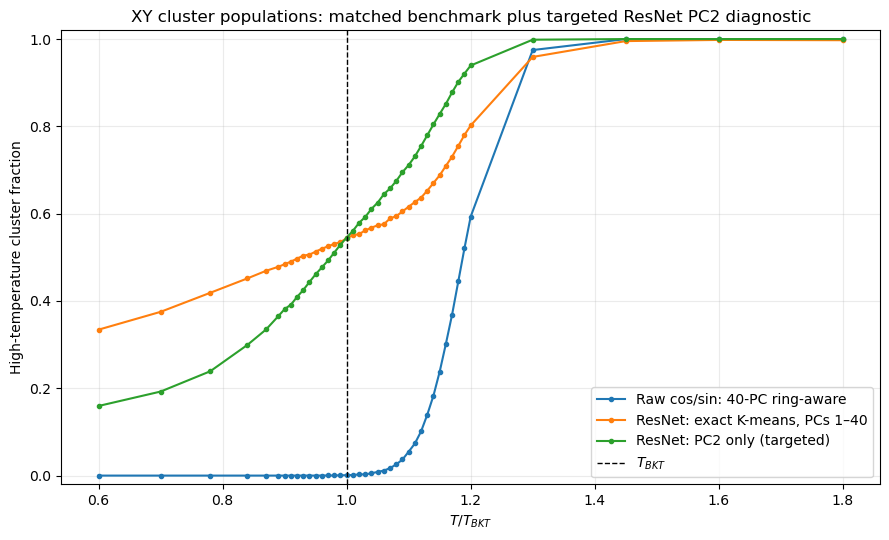

In [2]:
raw_pop=pd.read_csv(OUT/'raw_spin_cluster_populations.csv')
res_pop=pd.read_csv(OUT/'resnet18_cluster_populations.csv')
res_pc2_pop=pd.read_csv(OUT/'resnet18_pc2_cluster_populations.csv')
fig,ax=plt.subplots(figsize=(9,5.5))
for frame,label,color in ((raw_pop,'Raw cos/sin: 40-PC ring-aware','tab:blue'),(res_pop,'ResNet: exact K-means, PCs 1–40','tab:orange'),(res_pc2_pop,'ResNet: PC2 only (targeted)','tab:green')):
    high=frame[frame.cluster==1]
    ax.plot(high.T_over_TBKT,high.fraction,'o-',ms=3,label=label,color=color)
ax.axvline(1,color='black',ls='--',lw=1,label=r'$T_{BKT}$')
ax.set(xlabel=r'$T/T_{BKT}$',ylabel='High-temperature cluster fraction',title='XY cluster populations: matched benchmark plus targeted ResNet PC2 diagnostic',ylim=(-.02,1.02))
ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); fig.savefig(OUT/'xy32_raw_vs_resnet_cluster_comparison.png',dpi=220); plt.show(); plt.close(fig)


## Scientific interpretation

The raw and ResNet 40-PC rows remain the apples-to-apples, representation-blind comparison on the same 410,000 fit observations. Raw PC1–PC2 enter through their radius to respect the XY ring, while ResNet PCs enter directly. The ResNet 40-PC result uses exact Lloyd K-means; its near-identity to the earlier MiniBatch result shows that the weaker separation is not a minibatch artifact. The third row tests the specific hypothesis suggested by the PC plot: whether ResNet PC2 alone carries a cleaner phase-ordering coordinate. Because PC2 was selected after viewing its temperature trend, treat its stronger result as a targeted mechanistic diagnostic rather than an unbiased model-selection score. A larger silhouette means more internally coherent separation; AMI measures label agreement with the raw 40-PC clustering.